# Contingency Tables
## Assessing the similarity between two primary productivity (NetPP) products
### Comparing trends over time

> History | Updated Nov 2025

## Tutorial for this notebook

For this tutorial, we will be comparing **MODIS-Aqua** and **VIIRS-NOAA20**.

The process is divided into three mainsteps:

### 1. Long-Term Linear Trends in NetPP

We have already calculated the long-term linear trend for NetPP using linear regression analysis. Key details of the analysis include:

* **Pixel-by-Pixel Analysis:** Linear regression was applied over time to each pixel for  both legacy and interim NetPP products.

* **Output Results:** Pixel-by-pixel values were produced for:
    * The slope of the linear trend.
    
    * The number of observations used to calculate the trend (n).

    * The p-values for statistical significance.

* **Input Data:** Monthly NetPP data spanning a 5-year period (2018-2022) was used, providing maximum n = 60 per pixel.

    * Only pixels with a time series containing 50% of the maximum 60 points were included in the analysis.

![](slope_npp.png)

### 2. Constructing a Contingency Matrix

Using the results of the regression analysis, a contingency matrix is constructed to compare the trends between the legacy and interim product. Pixels are categorized by the matrix into three groups based on the sign of the slope:

1. **Positive Trend:** Increasing trend  (positive slope).

2. **Negative Trend:** Decreasing trend (negative slope).

3. **No significant Trend:** Slope not singificantly different than zero.

The contingency matrix shows the percentage of a pixels where the two NetPP products agree or disagree on the sign of the slope. 

### 3. Quantifying Agreement with Cohen's Kappa

The contingency matrix is used to compute Cohen's Kappa, a statistical measure that quantifies the level of agreement between the two NetPP products. Cohen's Kappa accounts for the agreement occuring by chance and provides a standardized metric of similarity.

## Datasets Overview
### Satellite-based NetPP data
The datasets used in the analysis were generated using the algorithm of Behrenfeld and Falkowski (1997). The primary productivity source datasets used for the regression analysis is global and monthly data from 2013-2022 that is placed on the NASA 9km Standard Mapped Image grid. The 10-year mean monthly values were substracted from each month to obtain the NetPP anomaly. 

#### Source Datasets

1. **Primary Productivity, MODIS Aqua, Science Quality, Global, 9km, 2013-2022, (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/productivity_modis_aqua_monthly_9km.graph

2. **Primary Productivity, VIIRS SNPP, Science Quality, Global, 9km, 2013-2022 (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/productivity_viirs_snpp_monthly_9km.graph

3. **Primary Productivity, VIIRS NOAA20, Science Quality, Global, 9km, 2018-2022, (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/productivity_viirs_noaa20_monthly_9km.graph

#### Regression Analysis Datasets

1. **Temporal Trends, Primary Productivity, VIIRS S-NPP, MODIS Aqua, Global, 9km, 2013 to 2022**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/netpp_trends_viirssnpp_and_modisaqua.graph

2. **Temporal Trends, Primary Productivity, VIIRS NOAA-20, MODIS Aqua, Global, 9km, 2018 to 2022.**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/netpp_trends_viirsnoaa20_and_modisaqua.graph

## Shapefiles

__Longhurst Marine Provinces__  

The dataset represents the division of the world oceans into provinces as defined by Longhurst (1995; 1998; 2006). This division has been based on the prevailing role of physical forcing as a regulator of phytoplankton distribution. The Longhurst Marine Provinces dataset is available online (https://www.marineregions.org/downloads.php) and within the shapes folder associated with this repository.

![](longhurst.png)


__For our example we will use the shapefile for the  "California Upwelling Coastal Province" (ProvCode: CCAL) within the Longhurst Marine Provinces classification__. 

## Resource requirements

- **Jupyter Notebook**

- **Python 3** with the modules included within the *Import packages* section below.

- **Shapefile**  of your area of interest.

    - This will be provided in the repository.

- **Internet connection**

## Import packages

In [1]:
import geopandas
import regionmask
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box

## Create global variables
Global variables are used to set up the file structure, directory paths, and template files required for making a contingency matrix.

* **BASE_DIR** is the base directory defined for the project, and the root for all other subdirectories.
* **RESOURCES_DIR** is where the Longhurst Provinces shapefile is located.

In [2]:
# Set global variables
BASE_DIR = "/Users/madisonrichardson/netpp"
RESOURCES_DIR = os.path.join(BASE_DIR, "resources")

## Create useful functions

### Function for loading trend data for the legacy and interim products

In [3]:
def xr_open_ds(
    e_id, e_source="https://coastwatch.pfeg.noaa.gov/wcn/erddap", dap="griddap"
):
    """
    Open a remote ERDDAP dataset as an Xarray dataset.

    Constructs the ERDDAP dataset URL using the provided dataset ID ('e_id'),
    server URL ('e_source'), and data access protocol ('dap'). Then it uses Xarray
    to open the dataset from the remote source.

    Args:
        e_id (str): ERDDAP dataset ID.
        e_source (str, optional): URL to ERDDAP server. Defaults to 'https://coastwatch.pfeg.noaa.gov/wcn/erddap'.
            You can change it to any ERDDAP server.
        dap (str, optional): The data access protocol type. Defaults to 'griddap' which is used for
        accessing gridded datasets.

    Returns:
        array: Xarray dataset object
    """
    # remove any trailing /
    e_source = e_source.rstrip("/")

    erddap_url = "/".join([e_source, dap, e_id])

    return xr.open_dataset(erddap_url)

### Function for finding common grid points among the two sources

In [4]:
def get_common_points(beta_data_list, pval_data_list):
    """
    Extract common grid points with valid data between two sources.

    This function identifies grid points where both datasets
    contain valid data, reshapes 2D beta and p-value arrays
    into 1D vectors for comparison, and returns the beta values,
    p-values, and count of common points. Zeros in beta and
    p-values are replaced with small values (0.00001) to
    prevent issues during processing.

    Args:
        beta_data_list (list of 2D arrays):
            A list containing beta values (slopes) for each source.
        pval_data_list (list of 2D arrays):
            A list containing p-values for each source.

    Returns:
        tuple:
            beta_common (list of 1D arrays):
                Beta values for the common grid points.
            pval_common (list of 1D arrays):
                P-values for the common grid points.
            num_common (int):
                Number of grid points common to both datasets.
    """
    beta_re_list = []
    pval_re_list = []
    ind_re_list = []

    for i in range(len(beta_data_list)):
        # Reshape 2D arrays into 1D vectors
        ny, nx = beta_data_list[i].shape
        beta_re = np.reshape(beta_data_list[i].data, ny*nx)
        pval_re = np.reshape(pval_data_list[i].data, ny*nx)

        # Find indices of finite values
        ind_re = np.isfinite(beta_re).nonzero()[0]

        # Replace zeros with small values
        trend_indices_1 = np.where(beta_re == 0.0)
        beta_re[trend_indices_1] = 0.00001
        pval_re[trend_indices_1] = 0.00001

        beta_re_list.append(beta_re)
        pval_re_list.append(pval_re)
        ind_re_list.append(ind_re)

    # Find common indices between the two datasets
    common_indices_12 = np.isin(ind_re_list[0], ind_re_list[1])
    common_indices_21 = np.isin(ind_re_list[1], ind_re_list[0])

    beta_common = [
        beta_re_list[0][ind_re_list[0]][common_indices_12],
        beta_re_list[1][ind_re_list[1]][common_indices_21]
    ]
    pval_common = [
        pval_re_list[0][ind_re_list[0]][common_indices_12],
        pval_re_list[1][ind_re_list[1]][common_indices_21]
    ]

    num_common = len(beta_common[0])

    return beta_common, pval_common, num_common


### Function for 2x2 Contingency Table

In [5]:
def make_2x2_contingency_table(beta_common, num_common, source_list):
    """
    Create a 2x2 contingency table comparing
    trends between two sources.

    This function compares the signs of trends (beta values) between two
    sources for common grid points and generates a 2x2 contingency table.
    The table represents the percentage of grid points that fall
    into each combination of positive and negative trends for the
    two sources.

    Args:
        beta_common (list):
            A list containing two 1D arrays of beta values
            for the grid points that are common between the
            two data sources. 'beta_common[0]' corresponds
            to the first source in 'source_list'. 
            'beta_common[1]' corresponds to the first
            source in 'source_list'. 
        num_common (int):
            The total number of grid points that are
            common between the two sources.
        source_list (list):
            A list of source names (e.g., ['modis', 'noaa20']).
            The first name corresponds to 'beta_common[0]', and
            the second corresponds to 'beta_common[1]'.

    Returns:
        tuple: A tuple containing the following:
            col_labels_2x2 (list): 
                Column labels for the contingency table
                indicating the trend direction for the first source (e.g.,
                `['MODIS $\\beta>=0$', 'MODIS $\\beta<0$']`).
            row_label_2x2 (list):
                Row labels for the contingency table
                indicating the trend direction for the second source (e.g.,
                `['NOAA20 $\\beta>=0$', 'NOAA20 $\\beta<0$']`).
            contingency_table_2x2 (numpy.ndarray):
                A 2x2 matrix representing the contingency table.
                Each cell contains the percentage of grid points
                that fall into the corresponding combination of trend
                directions.
            contingency_df_2x2 (pandas.DataFrame):
                A DataFrame representation of the contingency
                table with labeled rows and columns for easier
                visualization and interpretation.

    Contingency Table Structure:
        The table has two rows and two columns:
            Rows represent the trend direction for the second source
            (`source_list[1]`).
            Columns represent the trend direction for the first source
            (`source_list[0]`).
            Each cell represents the percentage of grid points where the
            specified trend combination is observed.

    Notes:
        Positive trends are identified as beta values greater than or equal
        to 0, and negative trends are identified as beta values less than 0.
        Percentages in the contingency table are normalized to the total
        number of common grid points (`num_common`).
        The function ensures compatibility with numpy arrays for efficient
        computation.
    """
    # Define the labels for a table
    operator_lbl = [r'$\beta>=0$', r'$\beta<0$']
    col_labels_2x2 = []
    row_label_2x2 = []
    for i in range(2):
        col_labels_2x2.append(
            '{} {}'.format(source_list[0].upper(),
                           operator_lbl[i])
        )
        row_label_2x2.append(
            '{} {}'.format(source_list[1].upper(),
                           operator_lbl[i])
        )

    # Define trend sign combinations for the contingency table
    trend_sign_combos = [[1, 1], [-1, 1], [1, -1], [-1, -1]]
    # Intialize the table as a vector
    table22_vec = np.zeros(len(trend_sign_combos))

    # Intialize the table as a vector
    trend_sign_combos = [[1, 1], [-1, 1], [1, -1], [-1, -1]]
    table22_vec = np.zeros(len(trend_sign_combos))
    for i in range(len(trend_sign_combos)):
        # Identify points with the specified trends
        sign_combo = trend_sign_combos[i]
        trend_indices_1 = np.where(sign_combo[0]*beta_common[0] > 0)[0]
        trend_indices_2 = np.where(sign_combo[1]*beta_common[1] > 0)[0]
        common_indices_sig1 = np.isin(trend_indices_1, trend_indices_2)
        num1 = len(common_indices_sig1.nonzero()[0])
        table22_vec[i] = 100*num1/num_common

    # Convert vector to 2x2 matrix
    contingency_table_2x2 = table22_vec.reshape(2, 2)

    # Create a Pandas DataFrame from the 2x2 table
    contingency_df_2x2 = pd.DataFrame(
        contingency_table_2x2, columns=col_labels_2x2
    )
    contingency_df_2x2 = contingency_df_2x2.set_index(
        np.array(row_label_2x2)
    )

    return (
        col_labels_2x2,
        row_label_2x2,
        contingency_table_2x2, 
        contingency_df_2x2
    )


### Function for 3x3 Contingency Table

In [6]:
def make_3x3_contingency_table(
        beta_common,
        pval_common,
        num_common,
        source_list,
        alpha = 0.05
):
    """
    Create a 3x3 contingency table comparing trends and
    significance levels between two sources.

    This function analyzes the relationship between
    trends (beta values) and their statistical significance
    (p-values) for two datasets. It calculates percentages
    of grid points falling into combinations of non-significant 
    (n.s.), positive trends (β ≥ 0), and negative trends (β < 0) 
    for each source, with significance determined by a
    threshold `alpha`.

    Args:
        beta_common (list):
            A list containing two 1D arrays of beta values (e.g., trends or 
            slopes) for the grid points common between the two data sources.
            `beta_common[0]`: Beta values for the first source in `source_list`.
            `beta_common[1]`: Beta values for the second source in `source_list`.
        pval_common (list):
            A list containing two 1D arrays of p-values for the grid points 
            common between the two data sources.
            `pval_common[0]`: P-values for the first source in `source_list`.
            `pval_common[1]`: P-values for the second source in `source_list`.
        num_common (int):
            The total number of grid points common to both sources.
            This is used as the denominator to calculate percentages.
        source_list (list):
            A list of source names (e.g., ['modis', 'noaa20']). The first name 
            corresponds to `beta_common[0]` and `pval_common[0]`, and the second 
            corresponds to `beta_common[1]` and `pval_common[1]`.
        alpha (float):
            The significance threshold for p-values (e.g., 0.05).
            Grid points with p-values below this threshold are
            considered statistically significant.

    Returns:
        tuple: A tuple containing the following:
            col_labels_3x3 (list):
                Column labels for the contingency table, 
                indicating the trend categories for the first source 
                e.g., ['MODIS n.s.', 'MODIS $\\beta>=0$', 'MODIS $\\beta<0$']).
            row_label_3x3 (list): 
                Row labels for the contingency table, 
                indicating the trend categories for the second source 
                (e.g., ['NOAA20 n.s.', 'NOAA20 $\\beta>=0$', 'NOAA20 $\\beta<0$']).
            contingency_table_3x3 (numpy.ndarray):
                A 3x3 matrix representing the contingency table. Each cell
                contains the percentage of grid points in the corresponding
                combination of trend categories.
            contingency_df_3x3 (pandas.DataFrame): 
                A DataFrame representation of the 3x3 contingency table with
                labeled rows and columns, providing easier visualization and
                interpretation.

    Contingency Table Categories:
        Rows and columns represent the trend categories for the two sources:
            Non-significant (n.s.): 
                Grid points with p-values ≥ alpha.
            Positive trend (β ≥ 0): 
                Grid points with significant trends and 
                positive beta values.
            Negative trend (β < 0): 
                Grid points with significant trends and 
                negative beta values.
        Each cell represents the percentage of grid points that fall into 
        the combination of trend categories for the two sources.

     Notes:
        Percentages are calculated relative to the total number of common 
        grid points (`num_common`). This function assumes that `beta_common`
        and `pval_common` are aligned such that their indices correspond
        to the same grid points in both sources. Positive and negative
        trends are determined only for significant grid points
        (p-values < alpha).
    """

    # Initialize the 3x3 table
    contingency_table_3x3 = np.zeros([3, 3])

    # Define and create labels for the 3x3 matrix
    operator_lbl = ['n.s.', r'$\beta>=0$', r'$\beta<0$']
    col_labels_3x3 = []
    row_label_3x3 = []
    for i in range(3):
        col_labels_3x3.append(
            '{} {}'.format(source_list[0].upper(), operator_lbl[i])
        )
        row_label_3x3.append(
            '{} {}'.format(source_list[1].upper(), operator_lbl[i])
        )

    # Calculate values for the first row/column in non-significant cases (ns)
    ns_indices_1 = np.where(pval_common[0] >= alpha)[0]
    ns_indices_2 = np.where(pval_common[1] >= alpha)[0]
    common_indices_ns = np.isin(ns_indices_1, ns_indices_2).nonzero()[0]
    contingency_table_3x3[0, 0] = 100*len(common_indices_ns)/num_common

    # Calculate when beta1 is ns and beta2 is sig (pos/neg trends)
    # Identify indices in the beta2 where trends are sig
    sig_indices_2 = np.where(pval_common[1][ns_indices_1] < alpha)[0]

    # Extract sig beta values from beta2
    beta2_sig = beta_common[1][ns_indices_1][sig_indices_2]

    # Separate sig beta2 values into pos and neg trends
    in2_sig_pos = np.where(beta2_sig >= 0)[0]
    in2_sig_neg = np.where(beta2_sig < 0)[0]

    # Calculate the percentage of positive and negative trends for beta2
    contingency_table_3x3[1, 0] = 100*len(in2_sig_pos)/num_common  # % of pos trends when beta1 is ns
    contingency_table_3x3[2, 0] = 100*len(in2_sig_neg)/num_common  # % of neg trends when beta1 is ns

    # Calculate the percentage of positive and negative trends for beta2
    contingency_table_3x3[1, 0] = 100*len(in2_sig_pos)/num_common  # % of pos trends when beta1 is ns
    contingency_table_3x3[2, 0] = 100*len(in2_sig_neg)/num_common  # % of neg trends when beta1 is ns

    # Calculate when beta2 is ns and beta1 is sig (pos/neg trends)
    # Identify indices in the beta1 where trends are sig
    sig_indices_1 = np.where(pval_common[0][ns_indices_2] < alpha)[0]

    # Extract the sig beta1 values
    beta1_sig = beta_common[0][ns_indices_2][sig_indices_1]

    # Separate sig beta1 values into pos/neg trends
    trend_indices_2_sig_pos = np.where(beta1_sig >= 0)[0]
    trend_indices_2_sig_neg = np.where(beta1_sig < 0)[0]

    # Calculate the percentage of pos trends for beta1
    contingency_table_3x3[0, 1] = 100*len(trend_indices_2_sig_pos)/num_common  # % of pos trends when beta2 is ns
    contingency_table_3x3[0, 2] = 100*len(trend_indices_2_sig_neg)/num_common  # % of neg trends when beta2 is ns

    # Calculate when both beta1 and beta2 have sig trends
    # Identify sig trends for both datasets
    sig_indices_1 = np.where(pval_common[0] < alpha)[0]
    sig_indices_2 = np.where(pval_common[1] < alpha)[0]

    # Find common sig trends for both datsets
    common_indices_sig1 = np.isin(sig_indices_1, sig_indices_2).nonzero()[0]
    common_indices_sig2 = np.isin(sig_indices_2, sig_indices_1).nonzero()[0]

    # Extract beta values for common sig points
    reshaped_data = [
        beta_common[0][sig_indices_1][common_indices_sig1],
        beta_common[1][sig_indices_2][common_indices_sig2]
    ]

    # Define sign combinations for trends in both datasets
    trend_sign_combos = [[1, 1], [-1, 1], [1, -1], [-1, -1]]

    # Initialize a vector to store the percentages for each combo
    table33_vec = np.zeros(len(trend_sign_combos))

    # Calculate the percentage of grid points for each trend combo
    for i in range(len(trend_sign_combos)):
        sign_combo = trend_sign_combos[i]
        trend_indices_1 = np.where(sign_combo[0]*reshaped_data[0] > 0)[0]
        trend_indices_2 = np.where(sign_combo[1]*reshaped_data[1] > 0)[0]
        common_indices_sig1 = np.isin(trend_indices_1, trend_indices_2)
        num1 = len(common_indices_sig1.nonzero()[0])
        table33_vec[i] = 100*num1/num_common

    # Populate the lower-right 4 cells
    contingency_table_3x3[1:, 1:] = np.reshape(table33_vec, [2, 2])

    # Create a Pandas DataFrame from the 3x3 table
    contingency_df_3x3 = pd.DataFrame(
        contingency_table_3x3,
        columns=col_labels_3x3
    )
    contingency_df_3x3 = contingency_df_3x3.set_index(np.array(row_label_3x3))
    contingency_df_3x3 = np.round(contingency_df_3x3*100)/100

    return (
        col_labels_3x3,
        row_label_3x3,
        contingency_table_3x3,
        contingency_df_3x3
    )

### Function for finding Cohen's Kappa

In [7]:
def find_kappa(contingency_table):
    """
    Calculate Cohen's Kappa for a given contingency table.

    Cohen's Kappa is a statistical to quantify the level
    of agreement between the two NetPP products. It
    provides a summary metric on a scale of 0 to 1, where 1
    indicates perfect agreement and 0 indicates no agreement.

    Args:
        contingency_table (numpy.ndarray):
            A square matrix (e.g., 2x2, 3x3) representing the contingency 
            table. Each cell contains the count or percentage of observations 
            in the corresponding category combination. 
            - Rows typically represent categories from one source.
            - Columns represent categories from the second source.

    Returns:
        float:
            Cohen's Kappa statistic, ranging from -1 to 1:
                A value of 1 indicates perfect agreement.
                A value of 0 indicates agreement no better than chance.
                A negative value indicates agreement worse than chance.

    Formula:
        Cohen's Kappa is calculated as:

            kappa = (observed_agreement - expected_agreement)(1 - expected_agreement)
            
                Where:
                    The observed proportion of agreement is the sum of the 
                    diagonal elements divided by the total.
                    The expected proportion of agreement by chance, 
                    calculated from row and column marginal totals.

     Notes:
        The function assumes the input contingency table contains either 
        counts or percentages. For percentages, the table should sum to 100; 
        for counts, the table should sum to the total number of observations.
        Kappa values close to 1 indicate strong agreement, while values near 
        or below 0 indicate poor agreement.
    """

    # Calculate row and column sums
    row_sum = np.sum(contingency_table, axis=1)
    clmn_sum = np.sum(contingency_table, axis=0)

    # Calculate the trace
    trc_sum = np.trace(contingency_table)

    # Calculate the overall sum (total number of grid points)
    overall_sum = np.sum(row_sum)

    # Calculate expected freqs for agreement by chance
    expected_freqs = row_sum * clmn_sum / overall_sum
    expected_freqs_sum = np.sum(expected_freqs)

    # Compute kappa
    kappa = (trc_sum - expected_freqs_sum) / (overall_sum - expected_freqs_sum)

    return kappa

### Function for plotting contingency tables

In [8]:
def plot_contingency_table(
        table,
        column_labels,
        row_labels,
        title,
        kappa,
        cmap="Blues"
):
    """
    Plot a contingency table as a heatmap with
    percentage annotations and Cohen's Kappa.

    Args:
        table (numpy.ndarray): A 2D array representing the contingency table 
        values (e.g., percentages).
        column_labels (list): List of labels for the table's columns.
        row_labels (list): List of labels for the table's rows.
        title (str): Title for the heatmap plot.
        kappa (float): Cohen's Kappa statistic value to annotate on the plot.
        cmap (str, optional): Colormap for the heatmap. Defaults to "Blues".

    Returns:
        Displays the heatmap plot with annotations and kappa value.
    """

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot heatmap
    heatmap = ax.imshow(table, cmap=cmap, aspect='auto')

    # Add colorbar
    cbar = plt.colorbar(heatmap, ax=ax)
    cbar.set_label("Percentage (%)", rotation=270, labelpad=15)

    # Set axis labels
    ax.set_xticks(range(len(column_labels)))
    ax.set_xticklabels(column_labels, rotation=45, ha="right", fontsize=12)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=12)

    vmin, vmax = heatmap.get_clim()

    # Normalize the color scale so we can compare against midpoint
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # Add text annotations with adaptive color
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table[i, j]

            # Get the normalized intensity (0=low, 1=high)
            intensity = norm(value)

            # If it's above halfway up the scale, use white text
            text_color = "white" if intensity > 0.5 else "black"
            
            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=14
            )

    # Set the title
    ax.set_title(title, fontsize=14, pad=20)

    # Add Cohen's Kappa as a text annotation
    fig.text(
        0.5,
        0.02,
        f"Cohen's Kappa = {kappa:.2f}",
        ha="center",
        va="center",
        fontsize=14,
        color="blue"
    )

    # Adjust layout
    plt.tight_layout(rect=[0, 0.05, 1, 1])

    # Show the plot
    plt.show()


## Set input parameters

Intialize the parameters for contingency matrices construction. These parameters are used to configure the region of interest, data sources, time range, and statistical thresholds.

* **ProvCode**: The province code for the area of interest. You can use *"box"* for predefined lat/lon ranges or specify a Longhurst Province Code. For this tutorial we will be looking at California.

* **lat_rgn**: Latitude range for the region of interest in *[min_lat, max_lat]* format. You only need to specify when you are using *"box* for ProvCode.

* **lon_rgn**: Longitude range for the region of interest in *[min_lon, max_lon]* format. You only need to specify when you are using *"box* for ProvCode.

* **source1**: The first sensor for comparison. We are using **modis** for this tutorial.

* **source2**: The second sensor for comparison. We are using **noaa20** for this tutorial.


In [9]:
# Set input variables
ProvCode = "CCAL"  # or ProvCode = "box"
lat_rgn = [30, 48]
lon_rgn = [-130, -115]
source1 = 'modisaqua'
source2 = 'viirsnoaa20'

## Load Longhurst Provinces

Determine a region of interest either by using predefined coordinates or by extracting a bounding box from a specific Longhurst Province, based on a provided **ProvCode**. We defined the ProvCode in the code above as **CCAL** (California Current Coastal Province) for this tutorial. 

* Reads the Longhurst Provinces shapefile into a GeoPandas dataframe.

* Displays available province codes and ensures the provided ProvCode is valid, raising an error if it's not.

* Extracts the bounding box for the specified ProvCode.

* Saves the region of interest as bounding box coordinates.

In [10]:
# Determine region of interest
if ProvCode == 'box':
    # If 'box' is specified, use predefined longitude and latitude ranges
    rgn_wnt = [lon_rgn, lat_rgn]
else:
    # Load the Longhurst Provinces shape files into a geopandas dataframe
    shape_path = os.path.join(
        RESOURCES_DIR,
        'Longhurst',
        'Longhurst_world_v4_2010.shp'
    )
    shapefiles = geopandas.read_file(shape_path)

    # Display the available ProvCodes
    available_provcodes = shapefiles["ProvCode"].unique()
    print("Available ProvCodes:")
    col_width = 5
    for i in range(0, len(available_provcodes), col_width):
        print(" | ".join(available_provcodes[i:i + col_width]))

    # Locate the row with the ProvCode code
    prov_wnt = shapefiles.loc[shapefiles["ProvCode"] == ProvCode]

    # Check if the selected ProvCode exists
    if prov_wnt.empty:
        raise ValueError(
            f"Invalid ProvCode '{ProvCode}'. Please select one from the list above."
        )

    # Find the coordinates of the bounding box
    # The bounding box is the smallest rectangle that will completely 
    # enclose the province.
    # We will use the bounding box coordinates to subset the satellite data
    gs_bnds = prov_wnt.bounds

    # Save bounding boc coordinates as the region of interest
    rgn_wnt = [
        [gs_bnds.minx.item(), gs_bnds.maxx.item()],
        [gs_bnds.miny.item(), gs_bnds.maxy.item()]
    ]

Available ProvCodes:
BPLR | ARCT | SARC | NADR | GFST
NASW | NATR | WTRA | ETRA | SATL
NECS | CNRY | GUIN | GUIA | NWCS
MEDI | CARB | NASE | BRAZ | FKLD
BENG | MONS | ISSG | EAFR | REDS
ARAB | INDE | INDW | AUSW | BERS
PSAE | PSAW | KURO | NPPF | NPSW
TASM | SPSG | NPTG | PNEC | PEQD
WARM | ARCH | ALSK | CCAL | CAMR
CHIL | CHIN | SUND | AUSE | NEWZ
SSTC | SANT | ANTA | APLR


## Get data from ERDDAP

In [11]:
# For ERDDAP function
erddap_url = "https://coastwatch.pfeg.noaa.gov/wcn/erddap/"

ID = f"netpp_trends_{source2}_and_{source1}"

ds = xr_open_ds(
    e_source=erddap_url,
    e_id=ID
)
print("Trends Dataset:", ds)

Trends Dataset: <xarray.Dataset> Size: 224MB
Dimensions:     (latitude: 2160, longitude: 4320)
Coordinates:
  * latitude    (latitude) float64 17kB 89.96 89.88 89.79 ... -89.88 -89.96
  * longitude   (longitude) float64 35kB -180.0 -179.9 -179.8 ... 179.9 180.0
Data variables:
    modis_beta  (latitude, longitude) float32 37MB ...
    modis_pval  (latitude, longitude) float32 37MB ...
    modis_n     (latitude, longitude) float32 37MB ...
    viirs_beta  (latitude, longitude) float32 37MB ...
    viirs_pval  (latitude, longitude) float32 37MB ...
    viirs_n     (latitude, longitude) float32 37MB ...
Attributes: (12/44)
    acknowledgement:           The project was supported by funding from the ...
    cdm_data_type:             Grid
    contributor:               Dale Robinson, Isaac Schroeder, Madison Richar...
    contributor_role:          project management, development, production, d...
    Conventions:               CF-1.10, COARDS, ACDD-1.3
    creator_email:             erd.d

## Get region from Longhurst Province Shapefile

* If ProvCode='box', use geopandas to create a new GeoDataFrame.

* If Provcode='Longhurt', region from the province shape file.

* Create the region from the shape file.

In [12]:
# Extract lat and lon for region of interest
region_lons = ds['longitude'].sel(
    longitude=slice(rgn_wnt[0][0], rgn_wnt[0][1])
).data
region_lats = ds['latitude'].sel(
    latitude=slice(rgn_wnt[1][1], rgn_wnt[1][0])
).data

In [13]:
if ProvCode == 'box':
    # Create a rectangular box region if 'box' is specified
    box_rgn = box(
        region_lons[0],
        region_lats[0],
        region_lons[-1],
        region_lats[-1]
    )
    newdata = geopandas.GeoDataFrame(
        index=[0], crs='epsg:4326', geometry=[box_rgn]
    )
    region = regionmask.from_geopandas(newdata)
else:
    # Use the geometry of the selected Longhurst Province as the region
    region = regionmask.from_geopandas(prov_wnt)

## Mask the data based on region

* Mask the trend data for both source types

* Apply the mask to the DataArray using the 'where' function

* The 'where' function sets any gridpoints outside the mask to a NaN value

In [14]:
# Define source names
source_names = ["MODIS", "NOAA20"]

In [15]:
# Extract beta and pval variables for each source
beta_modis = ds["modis_beta"].squeeze().sel(latitude=region_lats, longitude=region_lons)
pval_modis = ds["modis_pval"].squeeze().sel(latitude=region_lats, longitude=region_lons)

beta_viirs = ds["viirs_beta"].squeeze().sel(latitude=region_lats, longitude=region_lons)
pval_viirs = ds["viirs_pval"].squeeze().sel(latitude=region_lats, longitude=region_lons)

# Build the mask once (same grid for both sources)
mask = region.mask(beta_modis.longitude, beta_modis.latitude)

# Apply mask to each source
beta_modis_mask = beta_modis.where(mask == region.numbers[0])
pval_modis_mask = pval_modis.where(mask == region.numbers[0])

beta_viirs_mask = beta_viirs.where(mask == region.numbers[0])
pval_viirs_mask = pval_viirs.where(mask == region.numbers[0])

# Package into lists for downstream functions
beta_data_list = [beta_modis_mask, beta_viirs_mask]
pval_data_list = [pval_modis_mask, pval_viirs_mask]

## Find common grid points that have trend values

Using *get_common_points*, extract common data points across the datasets.

* Prints the selected province (ProvCode) and bounding region coordinates (rgn_wnt).

In [16]:
beta_common, pval_common, num_common = get_common_points(
    beta_data_list,
    pval_data_list
)

print('Province: {}\n'.format(ProvCode))
print(
    'Region: {:6.2f} to {:6.2f}, {:6.2f} to {:6.2f}\n'.format(
        rgn_wnt[0][0], rgn_wnt[0][1], rgn_wnt[1][0], rgn_wnt[1][1]
        )
)

Province: CCAL

Region: -134.50 to -110.50,  16.50 to  51.38



## Construct Contingency Tables and Compute Cohen's Kappa

To assess the agreement between legacy MODIS-Aqua and interim VIIRS-NOAA20 products, we construct **2x2** and **3x3 contingency tables** and compute **Cohen's Kappa**.

The **2x2 contingency table** categorizes pixels based on whether both datasets exhibit **positive ($\beta>=0$) or negative ($\beta<0$) trends**.

The **3x3 table** introduces a **non-significant trend (n.s.)** category, which accounts for cases where trends do not meet statistical significance thresholds.

![](Contingency_figure.png){width="30%}

**Cohen's Kappa** quantifies the agreement between datasets, and ranges from **0 (no agreement)** to **1 (almost perfect agreement)**.

![](cohens_kappa.png){width="30%}

In [17]:
# Create 2x2 contingency table
(
    col_labels_2x2,
    row_label_2x2,
    contingency_table_2x2,
    contingency_df_2x2
) = make_2x2_contingency_table(
    beta_common,
    num_common,
    source_names
)
print('Contingency table 2 x 2:\n')
print(contingency_df_2x2)

# Create 3x3 contingency table
(
    col_labels_3x3,
    row_label_3x3,
    contingency_table_3x3,
    contingency_df_3x3
) = make_3x3_contingency_table(
    beta_common,
    pval_common,
    num_common,
    source_names
)
print('Contigency table 3 x 3:\n')
print(contingency_df_3x3)

Contingency table 2 x 2:

                   MODIS $\beta>=0$  MODIS $\beta<0$
NOAA20 $\beta>=0$         79.947216         2.734231
NOAA20 $\beta<0$           3.660596        13.657957
Contigency table 3 x 3:

                   MODIS n.s.  MODIS $\beta>=0$  MODIS $\beta<0$
NOAA20 n.s.             48.38              3.37             0.26
NOAA20 $\beta>=0$        6.22             39.99             0.00
NOAA20 $\beta<0$         0.91              0.00             0.87


In [18]:
# Find Cohen's Kappa for 2x2 and 3x3 Contingency Tables
kappa_2x2 = find_kappa(contingency_table_2x2)
kappa_3x3 = find_kappa(contingency_table_3x3)
print(f"2x2 Kappa: {kappa_2x2:.2f}")
print(f"3x3 Kappa: {kappa_3x3:.2f}")

2x2 Kappa: 0.77
3x3 Kappa: 0.79


## Create a Figure for Both Tables

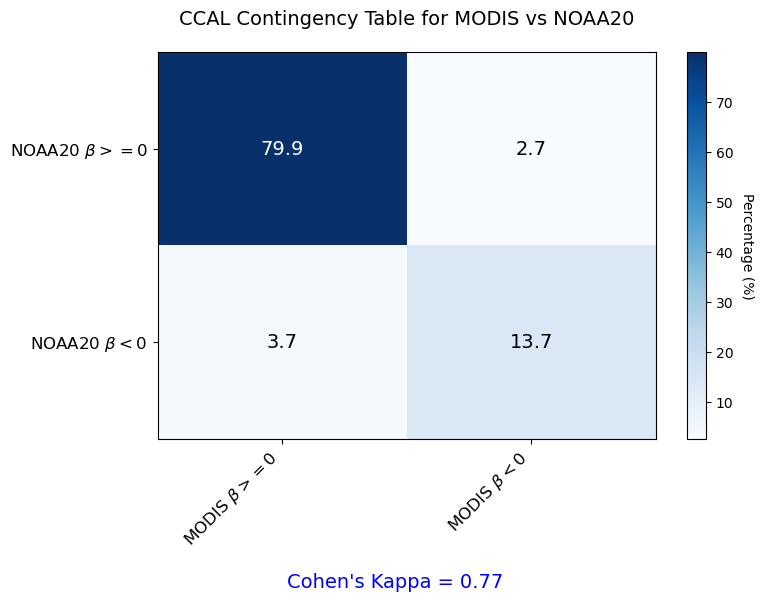

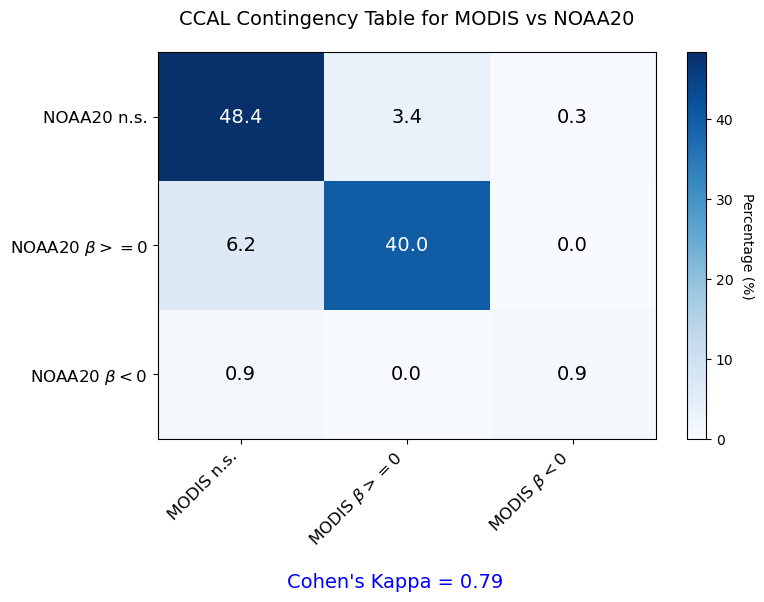

In [19]:
# 2x2 Table
plot_contingency_table(
    contingency_table_2x2,
    col_labels_2x2,
    row_label_2x2,
    title=f"{ProvCode} Contingency Table for {source_names[0].upper()} vs {source_names[1].upper()}",
    kappa=kappa_2x2,
    cmap="Blues"
)

# 3 x 3 Table
plot_contingency_table(
    contingency_table_3x3,
    col_labels_3x3,
    row_label_3x3,
    title=f"{ProvCode} Contingency Table for {source_names[0].upper()} vs {source_names[1].upper()}",
    kappa=kappa_3x3,
    cmap="Blues"
)

## Results:
- **Agreement between MODIS and NOAA20**:

    - The **2x2 contingency table** shows **93.6% agreement** for the direction of trends.
    
    - The **3x3 table** shows **89.3% agreement** for the direction of trends.

- **Cohen's Kappa Values**:

    - **2x2 Kappa**: 0.77 (substantial agreement)

    - **3x3 Kappa**: 0.79 (substantial agreement)